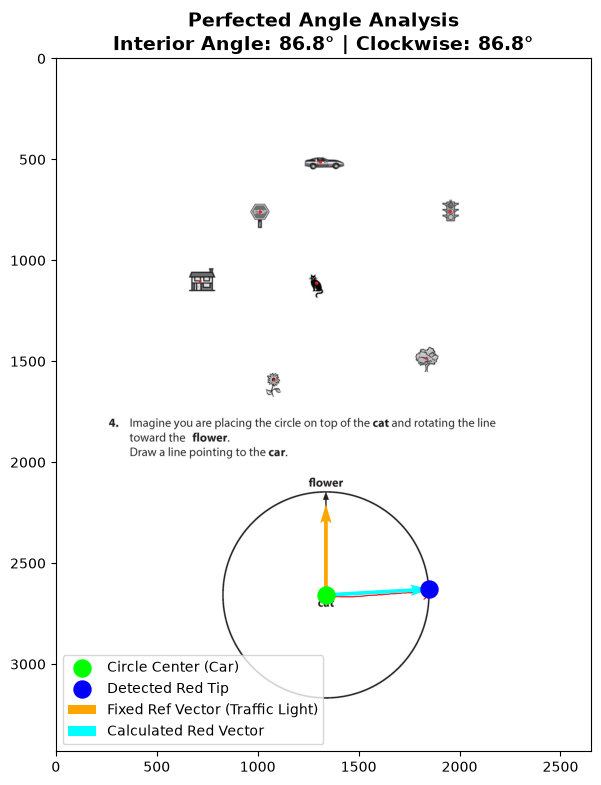

In [49]:
# THIS ONLY WORKS, because we have a red arrow in the image, hence the color detection can find the arrow. 

import cv2 
import numpy as np 
import matplotlib.pyplot as plt


def calculate_plot_angle(img_path):
    img = cv2.imread(img_path)
    if img is None: 
        print(f"Error: Unable to read image at {img_path}")
        return
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)


    # Using Hough circles to find the large diagram circle at the bottom 
    blurred = cv2.medianBlur(gray, 5)
    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp = 1, minDist = 500, 
        param1 = 50, param2 = 30, minRadius = 300, maxRadius=600
    )

    if circles is not None: 
        circles = np.uint16(np.around(circles))
        circle_x, circle_y, radius = circles[0][0]
    else: 
        circle_x, circle_y, radius = 1335, 2660, 500

    # Isole the arrow using HSV thresholding
    lower_red1 = np.array([0, 70, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 70, 50])
    upper_red2 = np.array([180, 255, 255])

    mask_red1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask_red2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask_red = cv2.bitwise_or(mask_red1, mask_red2)

    #Filter out any pixels which are outside the diagram circle radius
    roi_mask = np.zeros_like(mask_red)
    cv2.circle(roi_mask, (circle_x, circle_y), radius, 255, thickness=-1)
    mask_red = cv2.bitwise_and(mask_red, roi_mask)

    red_pts = np.argwhere(mask_red > 0)
    if len(red_pts) == 0:
        print("Counld not find any red points in the image.")
        return
    
    #3. Geometric arrow & arrow tip
    center_x, center_y = circle_x, circle_y
    distances = np.linalg.norm(red_pts - np.array([center_y, center_x]), axis=1)
    tip_idx = np.argmax(distances)
    red_tip_y, red_tip_x = red_pts[tip_idx]


    #4. Vector construction
    dx = red_tip_x - center_x
    dy = red_tip_y - center_y

    #5. Direct Clockwise angle calculation
    angle_clockwise = np.degrees(np.arctan2(dx, -dy))
    if angle_clockwise < 0:
        angle_clockwise += 360.0

    interior_angle = angle_clockwise if angle_clockwise <= 180 else 360 - angle_clockwise

    # 6. Plot the clean, fixed results
    plt.figure(figsize=(9, 9))
    plt.imshow(img_rgb)

    # Markers
    plt.scatter(center_x, center_y, color='lime', s=150, zorder=5, label='Circle Center (Car)')
    plt.scatter(red_tip_x, red_tip_y, color='blue', s=150, zorder=5, label='Detected Red Tip')

    # --- FIX IS HERE ---
    # Changed the y-component from a math expression to a direct pixel offset vector
    plt.quiver(center_x, center_y, 0, -450, angles='xy', scale_units='xy', scale=1, 
            color='orange', width=0.007, label='Fixed Ref Vector (Traffic Light)')

    plt.quiver(center_x, center_y, dx, dy, angles='xy', scale_units='xy', scale=1, 
            color='cyan', width=0.007, label='Calculated Red Vector')

    plt.title(f"Perfected Angle Analysis\nInterior Angle: {interior_angle:.1f}° | Clockwise: {angle_clockwise:.1f}°", 
              fontsize=14, fontweight='bold')
    plt.legend(loc='lower left')
    plt.axis('on')
    plt.show()

# Run it
calculate_plot_angle("participant01_Page_09.jpg")

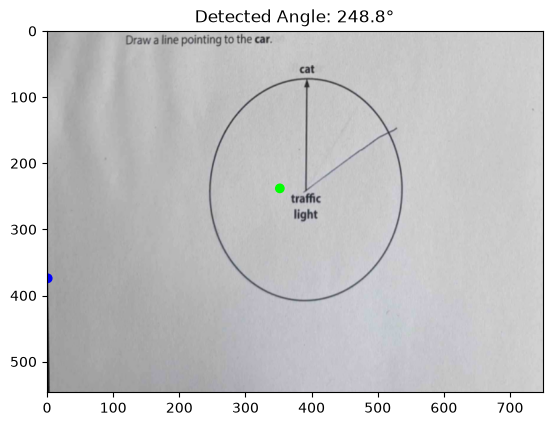

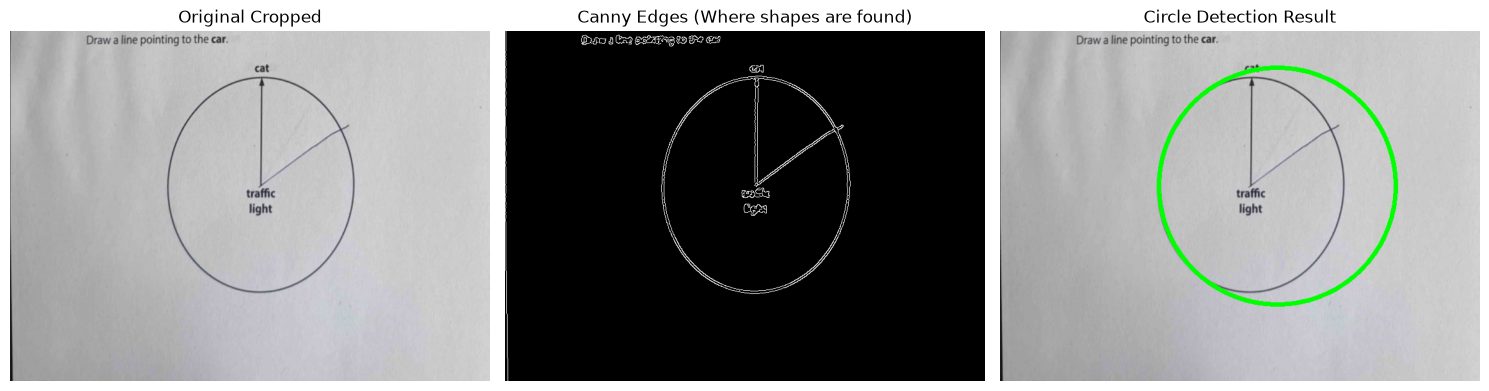

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def calculate_plot_angle(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print("Error: File not found.")
        return

    # 1. Pre-crop the image to the bottom half (where the diagram is)
    h, w, _ = img.shape
    img = img[int(h*0.5):h, 0:w]  # Keep bottom 50% of the image
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.medianBlur(gray, 5)

    # 2. Detect the circle in the cropped area
    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=1, minDist=200, 
        param1=50, param2=30, minRadius=100, maxRadius=400
    )

    if circles is not None:
        circle_x, circle_y, radius = np.uint16(np.around(circles[0][0]))
    else:
        print("Could not find the circle. Please check image quality.")
        return

    # 3. Line Detection (The "Color-Blind" approach)
    edges = cv2.Canny(blurred, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 50, minLineLength=50, maxLineGap=10)

    # Find the line that starts near the center
    tip_x, tip_y = circle_x, circle_y # Default
    for line in lines:
        x1, y1, x2, y2 = line[0]
        # Check which end of the line is further from the center
        d1 = np.hypot(x1 - circle_x, y1 - circle_y)
        d2 = np.hypot(x2 - circle_x, y2 - circle_y)
        if max(d1, d2) > radius * 0.5: # Ensure it's a significant line
            tip_x, tip_y = (x2, y2) if d1 < d2 else (x1, y1)
            break

    # 4. Calculation and Display
    dx, dy = tip_x - circle_x, tip_y - circle_y
    angle = np.degrees(np.arctan2(dx, -dy)) % 360
    
    # Plotting
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.scatter([circle_x, tip_x], [circle_y, tip_y], color=['lime', 'blue'])
    plt.title(f"Detected Angle: {angle:.1f}°")
    plt.show()

# Run the function on your specific file
calculate_plot_angle("test_data.jpg")

def visualize_processing_steps(img_path):
    img = cv2.imread(img_path)
    h, w, _ = img.shape
    img = img[int(h*0.5):h, 0:w]  # Crop to bottom half
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.medianBlur(gray, 5)
    
    # 1. Edge Detection Step
    edges = cv2.Canny(blurred, 50, 150)
    
    # 2. Circle Detection
    circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, 1.5, 200, 
                               param1=50, param2=45, minRadius=150, maxRadius=400)
    
    # Create a copy to draw findings
    display_img = img.copy()
    if circles is not None:
        c = np.uint16(np.around(circles[0][0]))
        cv2.circle(display_img, (c[0], c[1]), c[2], (0, 255, 0), 5)
        
    # Plotting everything
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original Cropped")
    
    axes[1].imshow(edges, cmap='gray')
    axes[1].set_title("Canny Edges (Where shapes are found)")
    
    axes[2].imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Circle Detection Result")
    
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_processing_steps("test_data.jpg")

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
 
 
def load_image(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return img
 
 
def detect_circle(gray):
    blurred = cv2.GaussianBlur(gray, (9, 9), 2)
    h, w = gray.shape
    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=h,
        param1=100,
        param2=60,
        minRadius=int(min(h, w) * 0.15),
        maxRadius=int(min(h, w) * 0.6),
    )
    if circles is None:
        raise RuntimeError("No circle detected. Try tuning HoughCircles params.")
    circles = np.round(circles[0, :]).astype(int)
    cx, cy, r = max(circles, key=lambda c: c[2])
    return cx, cy, r
 
 
def circular_mask(shape_hw, cx, cy, r, shrink=0.85):
    mask = np.zeros(shape_hw, dtype=np.uint8)
    cv2.circle(mask, (cx, cy), int(r * shrink), 255, thickness=-1)
    return mask
 
 
def extract_line_pixels(img_bgr, cx, cy, r, shrink=0.85, center_exclude=0.12):
    """
    Binarize ink strokes of ANY color (black, red, blue, etc.) inside
    the circle, WITHOUT pre-masking the color image to black first.
 
    IMPORTANT: masking the image to black outside the circle before
    thresholding creates an artificial hard edge exactly at the mask
    boundary, which adaptiveThreshold then detects as a false "line"
    (a full ring). To avoid this, thresholding runs on the ORIGINAL
    (unmasked) image, and the circular mask is applied afterward, only
    to the binary result.
 
    Also excludes a small disk at the circle's center, since that's
    typically covered by a text label (e.g. "car", "traffic light")
    which would otherwise pollute line-pixel detection.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray_thresh = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=25,
        C=10,
    )
 
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    sat = hsv[:, :, 1]
    _, sat_thresh = cv2.threshold(sat, 40, 255, cv2.THRESH_BINARY)
 
    combined = cv2.bitwise_or(gray_thresh, sat_thresh)
 
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    cleaned = cv2.morphologyEx(combined, cv2.MORPH_OPEN, kernel, iterations=1)
 
    # Apply circular mask AFTER thresholding (no false ring edge).
    mask = circular_mask(gray.shape, cx, cy, r, shrink=shrink)
    cleaned = cv2.bitwise_and(cleaned, cleaned, mask=mask)
 
    # Exclude small disk at center (removes center text label ink).
    if center_exclude > 0:
        center_mask = np.zeros_like(cleaned)
        cv2.circle(center_mask, (cx, cy), int(r * center_exclude), 255, -1)
        cleaned[center_mask > 0] = 0
 
    return cleaned
 
 
def detect_text_mask(img_bgr, cx, cy, r, padding=8):
    """
    Use OCR (pytesseract) to find printed label text (e.g. "car",
    "cat", "traffic light") inside the circle and build a mask that
    covers those regions, padded a bit for antialiasing/stroke width.
 
    This is more reliable than guessing by position or component size,
    since labels can sit at any distance from center and can visually
    touch a drawn line, merging into the same connected component.
    """
    import pytesseract
 
    text_mask = np.zeros(img_bgr.shape[:2], dtype=np.uint8)
    try:
        data = pytesseract.image_to_data(
            img_bgr, output_type=pytesseract.Output.DICT
        )
    except Exception:
        return text_mask  # OCR unavailable/failed -> no-op mask
 
    n = len(data.get("text", []))
    for i in range(n):
        word = data["text"][i].strip()
        conf = float(data.get("conf", ["-1"] * n)[i])
        if not word or conf < 30:
            continue
        x, y, w, h = (data["left"][i], data["top"][i],
                      data["width"][i], data["height"][i])
        # only care about text inside (or near) the circle
        wx, wy = x + w / 2, y + h / 2
        if np.hypot(wx - cx, wy - cy) > r * 1.05:
            continue
        x0, y0 = max(0, x - padding), max(0, y - padding)
        x1, y1 = min(img_bgr.shape[1], x + w + padding), min(img_bgr.shape[0], y + h + padding)
        text_mask[y0:y1, x0:x1] = 255
 
    return text_mask
 
 
def filter_line_like_components(binary_img, r, min_extent_frac=0.3, min_pixels=200):
    """
    Keep only connected components that look like real line strokes,
    discarding compact blobs such as text labels -- no matter where
    those labels happen to sit (center, edge, etc.).
 
    Note: since the two drawn lines share the same origin point (the
    circle's center), they typically merge into ONE connected
    component together (e.g. a V or X shape) rather than two separate
    elongated components. So we can't filter by elongation/aspect
    ratio alone -- a V-shape isn't "thin". Instead we filter by:
 
      - extent = bounding_box_long_side / r  (the merged line-blob
        spans a large fraction of the circle's radius; a stray text
        glyph does not)
      - pixel count (real strokes have far more ink pixels than a
        single text character)
 
    Components passing either threshold are kept.
    """
    num_labels, labels_im, stats, _ = cv2.connectedComponentsWithStats(
        binary_img, connectivity=8
    )
 
    keep_mask = np.zeros_like(binary_img)
    for label_id in range(1, num_labels):  # skip background label 0
        component = (labels_im == label_id).astype(np.uint8) * 255
        ys, xs = np.where(component > 0)
        if len(xs) < 8:
            continue
 
        pts = np.column_stack([xs, ys]).astype(np.float32)
        rect = cv2.minAreaRect(pts)
        (_, _), (w, h), _ = rect
        long_side = max(w, h)
        extent = long_side / r
 
        if extent >= min_extent_frac or len(xs) >= min_pixels:
            keep_mask = cv2.bitwise_or(keep_mask, component)
 
    return keep_mask
 
 
def pixel_radial_angles(binary_img, cx, cy):
    """For every ink pixel, compute its angle (0-360 deg) as seen from
    the circle center. Standard math convention: 0=east(+x), 90=north
    (-y in image coords since y grows downward)."""
    ys, xs = np.where(binary_img > 0)
    angles = np.degrees(np.arctan2(-(ys - cy), xs - cx)) % 360
    weights = np.hypot(xs - cx, ys - cy)  # farther pixels weighted more
    return angles, weights
 
 
def cluster_into_two_lines(angles, weights, n_lines=2):
    """
    Cluster per-pixel radial angles into n_lines groups via k-means on
    the unit circle (handles 0/360 wraparound correctly). Since these
    angles are already true directions from the center (not just
    orientations), no mod-180 ambiguity -- each cluster is one line's
    real pointing direction.
    """
    theta = np.radians(angles)
    pts = np.stack([np.cos(theta), np.sin(theta)], axis=1).astype(np.float32)
 
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, _ = cv2.kmeans(
        pts, n_lines, None, criteria, attempts=10, flags=cv2.KMEANS_PP_CENTERS
    )
    labels = labels.flatten()
 
    results = []
    for cluster_id in range(n_lines):
        mask = labels == cluster_id
        if not np.any(mask):
            continue
        w = weights[mask]
        cx_ = np.sum(w * pts[mask, 0]) / np.sum(w)
        cy_ = np.sum(w * pts[mask, 1]) / np.sum(w)
        mean_angle = np.degrees(np.arctan2(cy_, cx_)) % 360
        results.append({
            "angle_deg": mean_angle,
            "n_pixels": int(mask.sum()),
            "pixel_mask": mask,
        })
 
    results.sort(key=lambda r: -r["n_pixels"])
    return results[:n_lines]
 
 
def angle_between(line_a_deg, line_b_deg):
    """Smallest angle between two directions (0-180 deg)."""
    diff = abs(line_a_deg - line_b_deg) % 360
    return min(diff, 360 - diff)
 
 
def analyze_angle(path, show=True, figsize=(14, 6)):
    """
    Run the full pipeline and (optionally) display inline matplotlib
    debug plots — no files written to disk, good for notebooks.
 
    Returns a dict with cx, cy, r, clusters, and angle_deg.
    """
    img = load_image(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
 
    cx, cy, r = detect_circle(gray)
    binary_raw = extract_line_pixels(img, cx, cy, r)
 
    text_mask = detect_text_mask(img, cx, cy, r)
    binary_raw = cv2.bitwise_and(binary_raw, cv2.bitwise_not(text_mask))
 
    binary = filter_line_like_components(binary_raw, r)
    angles, weights = pixel_radial_angles(binary, cx, cy)
 
    if len(angles) < 20:
        raise RuntimeError(
            "Too few ink pixels detected inside the circle. Check the "
            "'Thresholded interior' plot -- thresholds may need tuning."
        )
 
    clusters = cluster_into_two_lines(angles, weights, n_lines=2)
 
    if len(clusters) < 2:
        raise RuntimeError("Could only find one dominant line orientation.")
 
    ang = angle_between(clusters[0]["angle_deg"], clusters[1]["angle_deg"])
 
    if ang < 2.0:
        print(
            "WARNING: the two detected clusters have nearly identical "
            "direction. This usually means only ONE real line was "
            "detected and k-means artificially split it in two. "
            "Inspect the 'Thresholded interior' plot below -- if only "
            "one line is visible there, the fainter line wasn't picked "
            "up by thresholding."
        )
 
    result = {
        "cx": cx, "cy": cy, "r": r,
        "clusters": clusters,
        "angle_deg": ang,
    }
 
    if show:
        debug = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
        cv2.circle(debug, (cx, cy), r, (0, 255, 0), 3)
 
        ys_all, xs_all = np.where(binary > 0)
        colors = [(255, 0, 0), (0, 0, 255)]
        for cluster, color in zip(clusters, colors):
            xs_c = xs_all[cluster["pixel_mask"]]
            ys_c = ys_all[cluster["pixel_mask"]]
            debug[ys_c, xs_c] = color
            # draw the fitted mean-direction arrow from center for clarity
            theta = np.radians(cluster["angle_deg"])
            end = (int(cx + r * np.cos(theta)), int(cy - r * np.sin(theta)))
            cv2.arrowedLine(debug, (cx, cy), end, color, 4, tipLength=0.05)
 
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        axes[0].imshow(binary, cmap="gray")
        axes[0].set_title("Thresholded interior")
        axes[1].imshow(debug)
        axes[1].set_title(f"Detected lines (angle={ang:.1f} deg)")
        axes[2].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[2].set_title("Original")
        for ax in axes:
            ax.axis("off")
        plt.tight_layout()
        plt.show()
 
        print(f"Circle center=({cx},{cy}) radius={r}")
        print(f"Line 1 direction: {clusters[0]['angle_deg']:.1f} deg "
              f"({clusters[0]['n_pixels']} pixels)")
        print(f"Line 2 direction: {clusters[1]['angle_deg']:.1f} deg "
              f"({clusters[1]['n_pixels']} pixels)")
        print(f"Angle between lines: {ang:.1f} degrees")
 
    return result

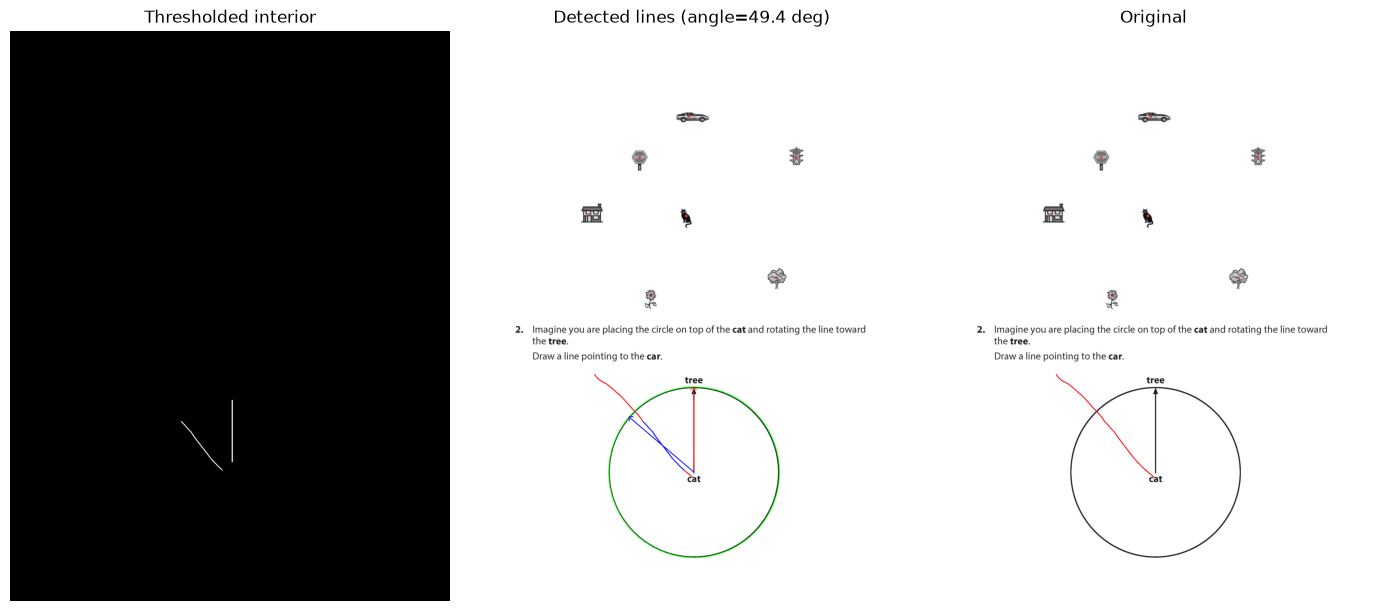

Circle center=(1339,2657) radius=514
Line 1 direction: 90.2 deg (2625 pixels)
Line 2 direction: 139.6 deg (2225 pixels)
Angle between lines: 49.4 degrees
49.409668871797436


In [46]:
result = analyze_angle("participant01_Page_07.jpg")   # shows inline debug plots
print(result["angle_deg"])